## Notebook 02 — Agglomerative and DBSCAN Comparison

In this notebook, I check whether two alternative clustering methods — Agglomerative Clustering and DBSCAN — can produce a better or more convincing credit-risk segmentation than the selected `v4` KMeans model.

The purpose is not to replace KMeans just for the sake of trying more algorithms. The selected production model remains KMeans unless another method produces a more interpretable, stable, and financially coherent credit-risk ladder. In other words, the alternative model must not only look better mathematically; it must also make better credit-analysis sense.

The comparison is performed on the same six bounded domain risk features used in the `v4` model. This keeps the test fair. I am not changing the underlying financial-risk space; I am only testing whether a different clustering algorithm organizes that space in a more useful way.


In [1]:
#Import your libraries here

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.credit_clustering.config import (
    DEFAULT_SEGMENT_COL,
    DEFAULT_TARGET_SEGMENTS,
    SCORECARD_CLUSTER_FEATURES,
    DEFAULT_RANDOM_STATE,
)

from src.credit_clustering.alternative_clustering import (
    build_method_comparison_table,
    define_alternative_clustering_pipelines,
    evaluate_agglomerative_grid,
    evaluate_dbscan_grid,
    load_table,
    make_label_crosstab,
    make_pca_projection,
    make_prepared_matrix,
    prepare_analysis_frame,
    profile_by_label,
    safe_internal_metrics,
    select_practical_dbscan_candidate,
    validate_required_paths,
)

### 1. Imports and project configuration

This notebook starts by importing the project configuration and the reusable helper functions from `src.credit_clustering.alternative_clustering`. The purpose is to keep the notebook focused on the comparison logic, while the repetitive technical work is handled by reusable source-code functions.

In this notebook, I am not rebuilding the main feature engineering or KMeans training workflow. That work has already been completed in the main model notebook. Here, I load the prepared model outputs and test whether alternative clustering methods can challenge the selected KMeans solution in a meaningful way.

The comparison focuses on two methods: Agglomerative Clustering and DBSCAN. Agglomerative Clustering is useful because it tests whether the observations form a hierarchical structure. DBSCAN is useful because it tests whether the data contains dense regions and outlier-like observations. These two methods look at the same six-dimensional credit-risk feature space from different angles.

The model definitions are shown explicitly before fitting so the comparison remains transparent. This is important because the goal is not just to run additional algorithms, but to understand whether they produce a more interpretable, stable, and financially coherent credit-risk segmentation than the selected v4 KMeans model.

This notebook therefore acts as a governance check. If an alternative method produces better internal metrics but weaker business interpretation, it should not automatically replace KMeans. The selected model should remain the one that best balances mathematical reasonableness, interpretability, scoring usability, and credit-analysis logic.

### 2. Paths and experiment settings

Notebook 02 uses the clustered panel exported by Notebook 01. The file is intentionally CSV because it is simple, portable, and avoids local Parquet issues.

In [2]:
# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "saved_models"
CURRENT_OUTPUT_DIR = OUTPUT_DIR / "credit_clustering_outputs_v4"
ALTERNATIVE_OUTPUT_DIR = CURRENT_OUTPUT_DIR / "alternative_clustering_v4"
ALTERNATIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "nonfinancial_credit_scorecard_kmeans_k5_v4.joblib"

CLUSTERED_PANEL_PATH = (
    CURRENT_OUTPUT_DIR / f"clustered_panel_v4_by_{DEFAULT_SEGMENT_COL}.csv"
)

CLUSTER_PROFILE_PATH = (
    CURRENT_OUTPUT_DIR / f"cluster_profile_v4_by_{DEFAULT_SEGMENT_COL}.csv"
)

CLUSTER_METRICS_PATH = (
    CURRENT_OUTPUT_DIR / f"cluster_metrics_v4_by_{DEFAULT_SEGMENT_COL}.csv"
)

K_TESTS_PATH = (
    CURRENT_OUTPUT_DIR / f"cluster_k_tests_v4_by_{DEFAULT_SEGMENT_COL}.csv"
)

# ---------------------------------------------------------------------
# Segment and feature configuration
# ---------------------------------------------------------------------

SEGMENT_COL = DEFAULT_SEGMENT_COL
TARGET_SEGMENT = DEFAULT_TARGET_SEGMENTS[0]
FEATURE_COLS = SCORECARD_CLUSTER_FEATURES
BASELINE_CLUSTER_COL = "cluster"

# Keep this practical. Agglomerative/DBSCAN can become slow or memory-heavy.
MAX_ROWS_FOR_HEAVY_MODELS = 25_000
RANDOM_STATE = DEFAULT_RANDOM_STATE

# Agglomerative settings
AGGLOMERATIVE_K_VALUES = [3, 4, 5, 6, 7, 8]
AGGLOMERATIVE_LINKAGE = "ward"

# DBSCAN settings. DBSCAN is very sensitive to eps/min_samples.
DBSCAN_EPS_VALUES = [0.25, 0.35, 0.50, 0.75, 1.00, 1.25, 1.50]
DBSCAN_MIN_SAMPLES_VALUES = [10, 25, 50, 100]

required_paths = {
    "model artifact": MODEL_PATH,
    "clustered panel": CLUSTERED_PANEL_PATH,
    "cluster profile": CLUSTER_PROFILE_PATH,
    "cluster metrics": CLUSTER_METRICS_PATH,
    "k tests": K_TESTS_PATH,
}

validate_required_paths(required_paths)

print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)
print("Current output dir:", CURRENT_OUTPUT_DIR)
print("Alternative output dir:", ALTERNATIVE_OUTPUT_DIR)
print("Model path:", MODEL_PATH)
print("Clustered panel path:", CLUSTERED_PANEL_PATH)
print("Segment column:", SEGMENT_COL)
print("Target segment:", TARGET_SEGMENT)
print("Feature columns:", FEATURE_COLS)
print("All required artifacts found.")

Project root: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3
Output dir: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs
Current output dir: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v4
Alternative output dir: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v4\alternative_clustering_v4
Model path: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\saved_models\nonfinancial_credit_scorecard_kmeans_k5_v4.joblib
Clustered panel path: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v4\clustered_panel_v4_by_financial_flag.csv
Segment column: financial_f

### 3. Load Notebook 01 outputs

The clustered panel provides the row-level observations, the six model features, and the selected KMeans cluster labels. Review outputs are loaded for baseline comparison.

In [3]:
clustered_panel = load_table(
    CLUSTERED_PANEL_PATH,
    required_cols=[SEGMENT_COL, BASELINE_CLUSTER_COL] + FEATURE_COLS,
    label="clustered v4 modelling panel",
)

cluster_profile = load_table(
    CLUSTER_PROFILE_PATH,
    required_cols=[SEGMENT_COL, BASELINE_CLUSTER_COL, "issuer_years", "rating_style_rank", "rating_style_label"],
    label="cluster profile",
)

cluster_metrics = load_table(
    CLUSTER_METRICS_PATH,
    required_cols=["segment", "status", "rows", "features", "silhouette", "calinski_harabasz", "davies_bouldin"],
    label="cluster metrics",
)

k_tests = load_table(
    K_TESTS_PATH,
    required_cols=["segment", "k", "rows", "features", "silhouette", "calinski_harabasz", "davies_bouldin"],
    label="k-tests",
)

print("clustered_panel:", clustered_panel.shape)
print("cluster_profile:", cluster_profile.shape)
print("cluster_metrics:", cluster_metrics.shape)
print("k_tests:", k_tests.shape)

clustered_panel: (24957, 91)
cluster_profile: (5, 32)
cluster_metrics: (2, 10)
k_tests: (7, 9)


### 4. Prepare the analysis frame

The comparison uses the same bounded scorecard risk-feature space as the selected KMeans model. Missing feature values are median-imputed for the alternative algorithms.

In [4]:
analysis_df = prepare_analysis_frame(
    clustered_panel,
    segment_col=SEGMENT_COL,
    target_segment=TARGET_SEGMENT,
    feature_cols=FEATURE_COLS,
    baseline_cluster_col=BASELINE_CLUSTER_COL,
    max_rows=MAX_ROWS_FOR_HEAVY_MODELS,
    random_state=RANDOM_STATE,
)

prepared = make_prepared_matrix(analysis_df, FEATURE_COLS)
X = prepared.X
kmeans_labels = analysis_df[BASELINE_CLUSTER_COL].astype(int).to_numpy()

print("Analysis frame:", analysis_df.shape)
print("Feature matrix:", X.shape)
print("Baseline KMeans cluster counts:")
display(analysis_df[BASELINE_CLUSTER_COL].value_counts().sort_index().rename("rows").to_frame())

Analysis frame: (24957, 91)
Feature matrix: (24957, 6)
Baseline KMeans cluster counts:


,rows
cluster,
0,7103
1,2729
2,4765
3,5904
4,4456


### 5. Unfitted alternative model pipelines

Before fitting the alternative models, I explicitly define and display the pipelines used in the comparison. This makes the modelling choices visible and keeps the notebook transparent. The purpose is not only to run different algorithms, but to show exactly how the alternatives are configured before they are evaluated against the selected v3 KMeans model.

The first alternative method is **Agglomerative Clustering**. This is a hierarchical clustering method. Unlike KMeans, it does not start with centroids. Instead, it begins with individual observations and gradually merges them into larger groups based on distance. I test several values of `k` because the number of clusters is still a modelling choice. This allows me to compare whether a hierarchical method can produce a credit-risk ladder that is more coherent or more stable than the five-cluster KMeans model.

The selected linkage method is `ward`. Ward linkage is appropriate here because it tries to merge clusters in a way that minimizes the increase in within-cluster variance. This makes it conceptually close to the KMeans objective, which also focuses on compact groups in a Euclidean feature space. Since the model features are bounded, numeric, and directionally aligned, Ward linkage is a reasonable choice for testing whether a hierarchical structure exists in the same financial-risk space.

The second alternative method is **DBSCAN**. DBSCAN is a density-based clustering algorithm. It does not require the number of clusters to be specified in advance. Instead, it groups observations that are close to each other and labels sparse observations as noise. This makes DBSCAN useful as an outlier and density diagnostic. In a credit-risk context, this is interesting because very weak or unusual companies may behave more like outliers than members of cleanly separated clusters.

For DBSCAN, I test a grid of `eps` and `min_samples` values. The `eps` parameter controls how close observations must be to count as neighbors. Smaller `eps` values create stricter density requirements and may produce more noise points. Larger `eps` values create broader neighborhoods and may merge many observations into one dominant cluster. The `min_samples` parameter controls how many neighboring observations are required to form a dense region. Higher values make the algorithm more conservative.

All alternative pipelines use `SimpleImputer(strategy="median")` before clustering. This keeps the preprocessing consistent with the selected KMeans pipeline and allows the comparison to focus on the clustering method itself rather than on a different missing-value treatment. The comparison is also performed on the same six bounded credit-risk features, so the underlying financial-risk space remains unchanged.

The displayed subset of pipelines is only a compact view for readability. It shows representative Agglomerative and DBSCAN configurations without flooding the notebook with every possible parameter combination. The full grid is still evaluated later in the notebook.


In [5]:
alternative_pipelines = define_alternative_clustering_pipelines(
    agglomerative_k_values=AGGLOMERATIVE_K_VALUES,
    dbscan_eps_values=DBSCAN_EPS_VALUES,
    dbscan_min_samples_values=DBSCAN_MIN_SAMPLES_VALUES,
    linkage=AGGLOMERATIVE_LINKAGE,
)

# Display a compact subset so the teacher can see the model definitions without flooding the notebook.
for name in [
    "agglomerative_k_3",
    "agglomerative_k_5",
    "agglomerative_k_8",
    "dbscan_eps_0.5_min_25",
    "dbscan_eps_1.0_min_50",
]:
    if name in alternative_pipelines:
        print("", name)
        print(alternative_pipelines[name])

 agglomerative_k_3
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', AgglomerativeClustering(n_clusters=3))])
 agglomerative_k_5
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', AgglomerativeClustering(n_clusters=5))])
 agglomerative_k_8
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', AgglomerativeClustering(n_clusters=8))])
 dbscan_eps_0.5_min_25
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', DBSCAN(min_samples=25))])
 dbscan_eps_1.0_min_50
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clusterer', DBSCAN(eps=1.0, min_samples=50))])


### 6. Baseline KMeans metrics

The selected v3 /latest version/ KMeans model is the benchmark. Alternative algorithms are evaluated against it using both internal metrics and label agreement metrics.

In [6]:
kmeans_internal_metrics = safe_internal_metrics(X, kmeans_labels)

if "segment" in cluster_metrics.columns:
    baseline_metric_row = cluster_metrics.loc[
        (cluster_metrics["segment"].astype(str) == TARGET_SEGMENT)
        & (cluster_metrics["status"].astype(str) == "clustered")
    ]
else:
    baseline_metric_row = pd.DataFrame()

if not baseline_metric_row.empty:
    baseline_metric_row = baseline_metric_row.iloc[0].to_dict()
else:
    baseline_metric_row = {}

kmeans_metrics = {
    "clusters": int(len(np.unique(kmeans_labels))),
    "silhouette": baseline_metric_row.get("silhouette", kmeans_internal_metrics["silhouette"]),
    "calinski_harabasz": baseline_metric_row.get("calinski_harabasz", kmeans_internal_metrics["calinski_harabasz"]),
    "davies_bouldin": baseline_metric_row.get("davies_bouldin", kmeans_internal_metrics["davies_bouldin"]),
}

pd.DataFrame([kmeans_metrics])

,clusters,silhouette,calinski_harabasz,davies_bouldin
0,5,0.304363,11906.580689,1.309946


## 7. Agglomerative clustering grid

Agglomerative clustering is used as a hierarchy check. It tests whether the credit-risk observations form similar groups under a hierarchical distance-based method.

In [7]:
agglo_results, agglo_labels_by_k = evaluate_agglomerative_grid(
    X=X,
    k_values=AGGLOMERATIVE_K_VALUES,
    linkage=AGGLOMERATIVE_LINKAGE,
    baseline_labels=kmeans_labels,
)

agglo_results_sorted = agglo_results.sort_values(
    ["silhouette", "ari_vs_kmeans"],
    ascending=[False, False],
).reset_index(drop=True)

display(agglo_results_sorted)

,method,k,linkage,clusters,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,Agglomerative,3,ward,3,0.285129,11833.383940,1.076185,0.341998,0.490866
1,Agglomerative,8,ward,8,0.246404,7898.026376,1.367719,0.527384,0.587839
2,Agglomerative,5,ward,5,0.245032,9694.650644,1.369918,0.461863,0.555721
3,Agglomerative,7,ward,7,0.243102,8353.673694,1.330600,0.501869,0.571477
4,Agglomerative,4,ward,4,0.237945,10152.526019,1.554952,0.414883,0.506613
5,Agglomerative,6,ward,6,0.237548,8991.345818,1.366241,0.495214,0.586207


### Agglomerative clustering outcome review

The Agglomerative Clustering results are useful because they challenge the selected KMeans model from a different angle. KMeans builds the groups around centroids, while Agglomerative Clustering builds them hierarchically by gradually merging observations into larger groups. If both methods find a broadly similar structure, this gives me additional comfort that the feature space is not completely arbitrary.

The first thing I look at is whether Agglomerative Clustering gives better internal clustering quality. The best Agglomerative result by silhouette score is the three-cluster version, with a silhouette score of approximately `0.285`. The silhouette score measures whether observations are closer to their own cluster than to neighboring clusters, so higher is better. This result is reasonable for a real-world credit dataset, but it is still lower than the selected five-cluster KMeans model, which has a silhouette score of approximately `0.304`.

The three-cluster Agglomerative solution also creates a business problem. It may be mathematically acceptable, but it is too coarse for the purpose of this project. A three-bucket credit model would probably separate companies into broad lower-risk, middle-risk, and higher-risk groups, but it would not give enough distinction between good, loss-making / cash-flow weak, leveraged / weak operating, and distressed profiles. For a credit-risk benchmarking tool, that loss of granularity is important.

The five-cluster Agglomerative result is the closest direct comparison to the selected five-cluster KMeans model. Here, the Adjusted Rand Index is approximately `0.462`, and the Normalized Mutual Information score is approximately `0.556`. These two metrics compare the Agglomerative labels with the KMeans labels. They do not tell me whether either model is “correct”; they tell me how similar the two segmentation structures are. Values around `0.45` to `0.56` mean that the two methods are not identical, but they are also not random relative to each other. In practical terms, this tells me that Agglomerative Clustering is seeing a related structure in the same credit-risk feature space.

However, the five-cluster Agglomerative model does not outperform KMeans. Its silhouette score is approximately `0.245`, compared with approximately `0.304` for KMeans. Its Calinski-Harabasz score is approximately `9,695`, compared with approximately `11,907` for KMeans. This matters because the Calinski-Harabasz score measures whether clusters are separated from each other while remaining compact internally. Higher is better, so this result favors KMeans. The Davies-Bouldin score also favors KMeans: Agglomerative has approximately `1.37`, while KMeans has approximately `1.31`. The Davies-Bouldin score measures how similar each cluster is to its nearest neighboring cluster, so lower is better. A lower value means less overlap and cleaner separation.

So the conclusion is not that Agglomerative Clustering failed. Actually, it is useful evidence. It shows that another unsupervised method finds a structure that partly overlaps with KMeans. That supports the idea that the engineered financial-risk features contain meaningful information. But Agglomerative Clustering does not produce a better five-cluster credit-risk ladder based on the internal metrics, and it does not improve the business interpretation enough to justify replacing KMeans.

The most important practical reason for staying with KMeans is the scoring use case. KMeans gives fitted centroids. After the model is trained, a new company can be transformed into the same six bounded credit-risk features and assigned directly to the nearest centroid. This is exactly what I need for Notebook 03, where the goal is to score manually entered or private-company financial data.

Agglomerative Clustering is less suitable for this production workflow because it is mainly designed to cluster the dataset it is fitted on. It does not naturally provide the same simple centroid-based `predict` logic for future unseen observations. For this project, the final objective is not only to analyze the SEC training universe, but to create a reusable scoring engine. For that reason, I keep KMeans as the selected model and treat Agglomerative Clustering as a useful governance check rather than a replacement.


### 8. DBSCAN grid

DBSCAN is used as a density and outlier diagnostic. It is not expected to produce an ordered credit-risk ladder as cleanly as KMeans, because it can return noise labels and highly uneven cluster sizes.

In [8]:
dbscan_results, dbscan_labels_by_params = evaluate_dbscan_grid(
    X=X,
    eps_values=DBSCAN_EPS_VALUES,
    min_samples_values=DBSCAN_MIN_SAMPLES_VALUES,
    baseline_labels=kmeans_labels,
)

dbscan_results_sorted = dbscan_results.sort_values(
    ["clusters_ex_noise", "noise_share", "largest_cluster_share", "silhouette"],
    ascending=[False, True, True, False],
).reset_index(drop=True)

display(dbscan_results_sorted)

,method,eps,min_samples,clusters_ex_noise,noise_share,largest_cluster_share,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,DBSCAN,0.25,10,5,0.016869,0.998003,-0.117432,25.370981,1.132328,0.001416,0.009431
1,DBSCAN,0.75,10,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
2,DBSCAN,0.75,25,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
3,DBSCAN,0.75,50,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
4,DBSCAN,0.75,100,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
5,DBSCAN,1.00,10,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
6,DBSCAN,1.00,25,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
7,DBSCAN,1.00,50,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
8,DBSCAN,1.00,100,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
9,DBSCAN,1.25,10,1,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000


### DBSCAN outcome review

The DBSCAN results show why DBSCAN is not suitable as the main model for this project. In most parameter combinations, DBSCAN produces only one non-noise cluster. When there is only one cluster, internal clustering metrics such as silhouette score, Calinski-Harabasz score, and Davies-Bouldin score are not defined, because these metrics require at least two clusters in order to measure separation and compactness. This is why most of the DBSCAN result table contains `NaN` values.

The practical interpretation is that DBSCAN sees the credit-risk feature space as one broad dense region rather than as several useful credit-risk groups. This is not surprising. The six credit-risk features are bounded between 0 and 1, and corporate credit quality is relatively continuous, which I discussed in the introduction section of the project. DBSCAN is designed to identify dense regions separated by sparse space, but this dataset does not appear to contain clear density gaps that would support a stable credit-risk ladder.

Only one tested configuration creates more than one non-noise cluster: `eps = 0.25` and `min_samples = 10`. However, this result is still not useful for the project. The largest cluster contains approximately `99.8%` of the non-noise observations, meaning the model effectively creates one dominant group and a very small secondary group. This does not provide a meaningful business segmentation.

The ARI and NMI values also confirm this conclusion. They are close to zero, which means the DBSCAN labels have almost no agreement with the selected KMeans segmentation. In other words, DBSCAN is not finding the same credit-risk structure from a different angle; it is mostly failing to separate the observations into usable groups.

For this reason, I treat DBSCAN as an outlier and density diagnostic, not as a replacement model. It is useful because it tells me something important: the dataset does not naturally break into density-separated credit-risk islands. This supports my earlier assumption that corporate credit quality behaves more like a continuous financial-risk space than a set of sharply separated natural clusters. Therefore, a centroid-based method such as KMeans remains more appropriate for building a practical five-level credit-risk benchmarking tool.

## 9. Select practical alternative candidates

The best mathematical metric is not enough. The selected candidate must also avoid excessive noise, a single dominant cluster, and uninterpretable segmentation.

In [9]:
best_agglo_row = agglo_results_sorted.iloc[0]
best_agglo_k = int(best_agglo_row["k"])
best_agglo_labels = agglo_labels_by_k[best_agglo_k]

best_dbscan_row = select_practical_dbscan_candidate(
    dbscan_results,
    max_noise_share=0.50,
    max_largest_cluster_share=0.90,
    min_clusters=2,
)

if best_dbscan_row is not None:
    best_dbscan_eps = float(best_dbscan_row["eps"])
    best_dbscan_min_samples = int(best_dbscan_row["min_samples"])
    best_dbscan_labels = dbscan_labels_by_params[(best_dbscan_eps, best_dbscan_min_samples)]
else:
    best_dbscan_eps = None
    best_dbscan_min_samples = None
    best_dbscan_labels = None

print("Best Agglomerative k:", best_agglo_k)
display(pd.DataFrame([best_agglo_row]))

if best_dbscan_row is not None:
    print("Best practical DBSCAN:", (best_dbscan_eps, best_dbscan_min_samples))
    display(pd.DataFrame([best_dbscan_row]))
else:
    print("No practical DBSCAN candidate met the noise/dominance criteria.")

Best Agglomerative k: 3


,method,k,linkage,clusters,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,Agglomerative,3,ward,3,0.285129,11833.38394,1.076185,0.341998,0.490866


No practical DBSCAN candidate met the noise/dominance criteria.


### Best alternative candidate outcome

The best Agglomerative Clustering candidate is the `k = 3` model with Ward linkage. It has the highest silhouette score among the Agglomerative alternatives, at approximately `0.285`, and a Calinski-Harabasz score of approximately `11,833`. This makes it the strongest hierarchical alternative from a statistical perspective.

However, the result is still not strong enough to replace the selected KMeans model. First, the three-cluster structure is too coarse for the intended five-level credit-risk ladder. Second, its ARI of approximately `0.342` and NMI of approximately `0.491` show only moderate agreement with KMeans. This means it detects some related structure, but not a clearly superior segmentation.

No practical DBSCAN candidate met the noise and dominance criteria. This confirms that DBSCAN does not produce a usable credit-risk segmentation on this feature space. Overall, the alternative-method review supports keeping KMeans as the production model, while treating Agglomerative Clustering and DBSCAN as useful governance checks.


### 10. Attach alternative labels and compare with KMeans

ARI and NMI quantify agreement with the selected KMeans segmentation. Crosstabs show how observations migrate between labels.

In [10]:
analysis_df = analysis_df.copy()
analysis_df["agglomerative_cluster"] = best_agglo_labels

if best_dbscan_labels is not None:
    analysis_df["dbscan_cluster"] = best_dbscan_labels

print("KMeans vs best Agglomerative crosstab:")
display(
    make_label_crosstab(
        kmeans_labels,
        best_agglo_labels,
        reference_name="kmeans_cluster",
        alternative_name="agglomerative_cluster",
        normalize="index",
    )
)

if best_dbscan_labels is not None:
    print("KMeans vs practical DBSCAN crosstab:")
    display(
        make_label_crosstab(
            kmeans_labels,
            best_dbscan_labels,
            reference_name="kmeans_cluster",
            alternative_name="dbscan_cluster",
            normalize="index",
        )
    )

KMeans vs best Agglomerative crosstab:


agglomerative_cluster,0,1,2
kmeans_cluster,,,
0,0.350978,0.005913,0.643109
1,0.327226,0.621107,0.051667
2,0.997482,0.002518,0.000000
3,0.913618,0.086382,0.000000
4,0.013914,0.986086,0.000000


### KMeans versus best Agglomerative crosstab review

The crosstab compares the selected `v4` KMeans clusters with the best Agglomerative alternative, which is the three-cluster Ward model. The values are row-normalized, so each KMeans cluster is split across the three Agglomerative clusters.

The result is useful because it shows that Agglomerative Clustering does not create a completely random structure. Several KMeans clusters map strongly into one Agglomerative group. KMeans cluster `2`, which is the `Distressed / near-default proxy` group, maps almost entirely to Agglomerative cluster `0`, with approximately `99.7%` of its observations there. KMeans cluster `4`, which is the `Strong relative credit profile` group, maps almost entirely to Agglomerative cluster `1`, with approximately `98.6%` of its observations there. KMeans cluster `3`, the `Leveraged / weak operating credit profile` group, also maps mostly to Agglomerative cluster `0`, with approximately `91.4%` of its observations there.

At the same time, the crosstab shows why the Agglomerative solution is too coarse for the purpose of this project. Since Agglomerative uses only three clusters, it compresses several KMeans risk groups into broader buckets. For example, KMeans cluster `2` and KMeans cluster `3` both map mainly to Agglomerative cluster `0`, even though they represent different business interpretations in the final KMeans model: one is the `Distressed / near-default proxy` group, while the other is the `Leveraged / weak operating credit profile` group.

KMeans cluster `0`, which represents the `Loss-making / cash-flow weak profile`, is split between Agglomerative cluster `2` and Agglomerative cluster `0`: approximately `64.3%` falls into Agglomerative cluster `2`, while approximately `35.1%` falls into Agglomerative cluster `0`. This is an important result. It shows that the loss-making / cash-flow weak group is not simply identical to one hierarchical bucket. It sits between broader financial-risk structures, which supports the idea that the five-cluster KMeans model captures a more nuanced mid-risk profile.

KMeans cluster `1`, the `Good credit profile` group, is also split between Agglomerative cluster `1` and Agglomerative cluster `0`: approximately `62.1%` maps to Agglomerative cluster `1`, while approximately `32.7%` maps to Agglomerative cluster `0`. This again confirms that the three-cluster Agglomerative model captures broad structure, but loses some of the useful business separation between intermediate profiles.

Overall, the crosstab supports the final decision. Agglomerative Clustering captures meaningful broad structure in the same feature space, but it loses too much granularity. It is useful as a validation check because it confirms that the data has non-random organization. However, it does not provide a better business segmentation than KMeans. The selected `v4` KMeans model remains preferable because it preserves a five-level credit-risk ladder, separates loss-making/cash-flow weak companies from leveraged weak operating companies, and supports direct scoring of new company profiles.


### 11. Alternative cluster profiles

Profiles help determine whether alternative clusters are financially interpretable, not only mathematically separated.

In [11]:
PROFILE_EXTRA_COLS = [
    "scorecard_credit_score",
    "leverage_risk",
    "liquidity_risk",
    "earnings_risk",
    "operating_cashflow_risk",
    "debt_service_risk",
    "structural_distress_risk",
]

agglo_profile = profile_by_label(
    analysis_df,
    label_col="agglomerative_cluster",
    feature_cols=FEATURE_COLS,
    extra_cols=[col for col in PROFILE_EXTRA_COLS if col not in FEATURE_COLS],
)

display(agglo_profile)

if best_dbscan_labels is not None:
    dbscan_profile = profile_by_label(
        analysis_df,
        label_col="dbscan_cluster",
        feature_cols=FEATURE_COLS,
        extra_cols=[col for col in PROFILE_EXTRA_COLS if col not in FEATURE_COLS],
    )
    display(dbscan_profile)
else:
    dbscan_profile = pd.DataFrame()

,agglomerative_cluster,rows,median_structural_distress_risk,median_earnings_risk,median_operating_cashflow_risk,median_liquidity_risk,median_leverage_risk,median_debt_service_risk,median_scorecard_credit_score
0,0,13595,0.600000,0.815954,0.817888,0.621763,0.551200,0.918414,69.745284
1,1,6653,0.218623,0.243783,0.265946,0.309693,0.173289,0.102358,23.154468
2,2,4709,0.000000,1.000000,1.000000,0.013575,0.001251,1.000000,51.767438


### Business interpretability of the best Agglomerative candidate

The best Agglomerative candidate produces three broad groups with a clear financial interpretation, but the interpretation is still too compressed for the purpose of this project.

Agglomerative cluster `1` is the strongest group. It contains `6,653` observations and has the lowest median scorecard credit score, approximately `23.15`. Its median risk values are also clearly the strongest among the three Agglomerative groups: structural distress risk is approximately `0.22`, earnings risk `0.24`, operating cash-flow risk `0.27`, liquidity risk `0.31`, leverage risk `0.17`, and debt-service risk only `0.10`. This group behaves like a broad low-risk / good-quality financial profile.

Agglomerative cluster `2` is more specific. It contains `4,709` observations and has a median scorecard credit score of approximately `51.77`. The important feature is the shape of the risks: earnings risk, operating cash-flow risk, and debt-service risk are all at `1.00`, while liquidity risk is only approximately `0.01`, leverage risk is almost zero at approximately `0.00`, and structural distress risk is also `0.00`. This is very close to the `v4` KMeans idea of a loss-making / cash-flow weak profile: companies that are weak in earnings and cash-flow generation but are not necessarily leveraged or structurally distressed.

Agglomerative cluster `0` is the broad weak / elevated-risk group. It is the largest group, with `13,595` observations, and has the weakest median scorecard credit score, approximately `69.75`. Its risk indicators are elevated across most dimensions: structural distress risk is approximately `0.60`, earnings risk `0.82`, operating cash-flow risk `0.82`, liquidity risk `0.62`, leverage risk `0.55`, and debt-service risk `0.92`. This group combines many types of credit weakness into one large bucket.

These results are useful because they confirm that Agglomerative Clustering is finding meaningful structure in the same feature space. It separates a broad stronger group, a specialized loss-making / cash-flow weak group, and a broad elevated-risk group. This supports the idea that the engineered credit-risk features are not arbitrary.

However, the Agglomerative solution is still too compressed for the final application. The largest Agglomerative group, cluster `0`, combines several different credit situations into one bucket. In the final `v4` KMeans model, these are separated more clearly into `Leveraged / weak operating credit profile` and `Distressed / near-default proxy`, which is a much more useful distinction for credit-risk communication.

For this reason, Agglomerative Clustering is a good interpretability check but not a better production model. It supports the financial logic of the feature space, but it does not provide enough granularity for the intended scoring application. The selected `v4` KMeans model remains more useful because it separates the credit space into five interpretable risk levels and can assign new company profiles directly to trained centroids.



### 12. PCA visualization

PCA is used only for visualization. The clustering comparison itself is performed on the six bounded risk features after median imputation.

This step creates a two-dimensional PCA projection of the same six-dimensional credit-risk feature space used in the clustering comparison. The purpose is not to train a new model, but to visualize how the selected KMeans clusters and the best Agglomerative clusters are positioned in a lower-dimensional view.

The original feature space contains six bounded credit-risk dimensions. Since this cannot be directly shown on a two-dimensional chart, PCA is used to compress the feature matrix into two principal components, `PC1` and `PC2`. These components are linear combinations of the original risk features and are chosen to preserve as much variation as possible.

In this result, the first principal component explains approximately `45.4%` of the variance, while the second explains approximately `33.6%`. Together, the two-dimensional projection explains approximately `79.0%` of the total variance in the feature matrix. This means the plot captures a meaningful part of the structure in the original six-dimensional space, although it is still only a simplified projection.

The dataframe keeps both the selected KMeans cluster label and the Agglomerative cluster label for each observation. This allows me to compare the two clustering methods visually on the same PCA map. If the two methods separate the space in broadly similar ways, their labels should show some visible alignment. If they disagree strongly, the PCA plot should help reveal where the disagreement occurs.

This visualization is therefore a communication and diagnostic tool. It does not decide which model is better by itself. It helps me see whether the alternative clustering result supports or contradicts the selected KMeans segmentation in a way that is easier to interpret visually.

In [12]:
pca_df, pca_model = make_pca_projection(
    X,
    analysis_df,
    label_cols=[BASELINE_CLUSTER_COL, "agglomerative_cluster"] + (["dbscan_cluster"] if "dbscan_cluster" in analysis_df.columns else []),
    n_components=2,
    random_state=RANDOM_STATE,
)

print("PCA explained variance ratio:", pca_model.explained_variance_ratio_)
print("Total explained variance:", pca_model.explained_variance_ratio_.sum())

display(pca_df.head())

PCA explained variance ratio: [0.45361585 0.33606638]
Total explained variance: 0.7896822290824221


,PC1,PC2,cluster,agglomerative_cluster,explained_variance_ratio_sum
0,0.516062,0.854509,2,0,0.789682
1,0.171003,0.890844,3,0,0.789682
2,-0.197904,0.083203,3,0,0.789682
3,-1.101555,0.298510,4,1,0.789682
4,0.413698,-0.204611,0,0,0.789682


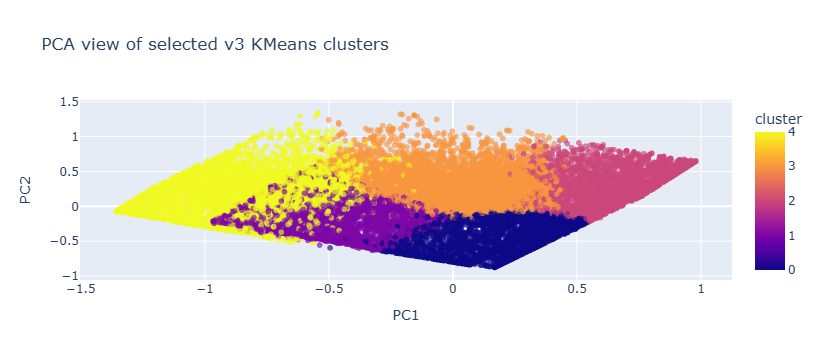

In [13]:
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color=BASELINE_CLUSTER_COL,
    title="PCA view of selected v3 KMeans clusters",
    opacity=0.65,
)
fig.show()

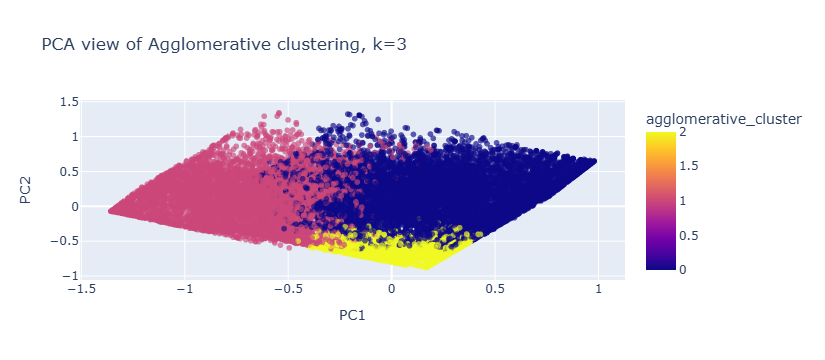

In [14]:
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="agglomerative_cluster",
    title=f"PCA view of Agglomerative clustering, k={best_agglo_k}",
    opacity=0.65,
)
fig.show()

Because no practical DBSCAN candidate met the noise and dominance criteria, I do not use a DBSCAN PCA visualization in the final comparison. The DBSCAN results already show that the method does not create a usable credit-risk segmentation in this feature space. For this reason, the visual comparison is focused on KMeans versus the best Agglomerative candidate.

### 13. Final method comparison

The selected method should not be based only on one metric. For this project, financial interpretability, stable five-level labelling, and private-company scoring compatibility matter more than maximizing a single unsupervised metric.

In [15]:
comparison_table = build_method_comparison_table(
    kmeans_metrics=kmeans_metrics,
    best_agglo_row=best_agglo_row,
    best_dbscan_row=best_dbscan_row,
)

display(comparison_table)

,method,selected_role,clusters,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans,comment
0,KMeans selected v3,Production model,5,0.304363,11906.580689,1.309946,1.000000,1.000000,Selected for stable five-level credit-risk lad...
1,Agglomerative best candidate,Robustness check,3,0.285129,11833.383940,1.076185,0.341998,0.490866,Useful hierarchy check; not selected because K...


### Final comparison outcome

The final comparison supports my decision to continue with the selected `v4` KMeans model. Agglomerative Clustering is useful as a robustness check and confirms that there is some related structure in the same credit-risk feature space. However, its best candidate uses only three clusters, which is too coarse for the intended five-level credit-risk ladder.

The selected KMeans model remains the better production choice because it provides a stable five-cluster structure, better business interpretability, centroid-based distance diagnostics, and direct assignment of new company profiles to trained centroids. This is important for Notebook 03, where the goal is not only to analyze historical SEC data, but to apply the saved artifact to manual or private-company scoring.

For this reason, Agglomerative Clustering and DBSCAN remain useful governance checks, but the final modelling decision remains unchanged: I continue with the `v4` KMeans model as the production credit-risk segmentation model.


### 14. Save alternative clustering outputs

In [16]:
agglo_results_sorted.to_csv(ALTERNATIVE_OUTPUT_DIR / "agglomerative_grid_results_v4.csv", index=False)
dbscan_results_sorted.to_csv(ALTERNATIVE_OUTPUT_DIR / "dbscan_grid_results_v4.csv", index=False)
comparison_table.to_csv(ALTERNATIVE_OUTPUT_DIR / "alternative_method_comparison_v4.csv", index=False)
agglo_profile.to_csv(ALTERNATIVE_OUTPUT_DIR / "agglomerative_profile_v4.csv", index=False)

if not dbscan_profile.empty:
    dbscan_profile.to_csv(ALTERNATIVE_OUTPUT_DIR / "dbscan_profile_v4.csv", index=False)

pca_df.to_csv(ALTERNATIVE_OUTPUT_DIR / "pca_projection_alternative_clustering_v4.csv", index=False)

print("Saved alternative clustering outputs to:", ALTERNATIVE_OUTPUT_DIR)

Saved alternative clustering outputs to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v4\alternative_clustering_v4


## 15. Conclusion

This notebook tested whether Agglomerative Clustering or DBSCAN could produce a better credit-risk segmentation than the selected `v4` KMeans model. I did not want to accept KMeans only because it was the first successful model. Since the whole project depends on the quality and interpretability of the clustering structure, I needed to challenge the model with other unsupervised methods.

Agglomerative Clustering was useful as a hierarchical robustness check. It showed that another clustering method can detect a related structure in the same six-dimensional credit-risk feature space. This gave me some comfort that the KMeans result is not completely arbitrary. However, the best Agglomerative candidate used only three clusters, which is too coarse for the business purpose of this project. It may separate the universe into broad lower-risk, elevated-risk, and weak cash-flow groups, but it does not provide the five-level credit-risk ladder I need for practical scoring and reporting.

DBSCAN was useful in a different way. It tested whether the data naturally forms density-separated groups or outlier regions. The result was also informative, but not in favor of DBSCAN as a production model. The DBSCAN grid did not produce a practical ordered segmentation. This tells me that the data does not behave like a set of clearly separated density islands. That is consistent with my original expectation that corporate credit quality is more continuous than sharply separated.

The final conclusion is that the `v4` KMeans model remains the best production choice. It provides a stable five-level credit-risk ladder, interpretable centroids, usable distance diagnostics, and direct compatibility with future scoring. This last point matters a lot. The objective of the project is not only to analyze the historical SEC dataset, but also to apply the trained model to new company profiles. KMeans makes that possible because a new observation can be transformed into the same six bounded credit-risk features and assigned to the nearest trained centroid.

For this reason, Agglomerative Clustering and DBSCAN remain valuable governance checks, but they do not replace the selected model. They helped me understand the structure of the feature space better and gave additional support to the decision to continue with KMeans.

Notebook 03 is the application notebook. In the next step, I will load the saved `v4` KMeans artifact and apply it to real company financial data. The goal will be to move from model comparison to actual scoring: calculate the same engineered features, assign the company to one of the trained credit-risk clusters, review distance and affinity diagnostics, apply guardrail checks, and generate the final Excel and PDF outputs. This is where the model becomes a practical credit-risk benchmarking tool rather than only a clustering experiment.